## 1. Setup and Configuration
**Experiment: Fine-tuning MegaDescriptor Backbone**

This notebook is based on the baseline but additionally fine-tunes the last 2 transformer blocks of MegaDescriptor (instead of keeping the entire backbone frozen). This allows the model to learn jaguar-specific features in the deepest layers while preserving general visual features everywhere else.

Key differences from baseline:
- Last 2 MegaDescriptor transformer blocks (= Stage 3) + norm layer are unfrozen
- The `unfreeze_blocks` parameter controls exactly how many blocks from the tail end are trainable
- Differential learning rates: backbone gets 10x lower LR than the projection/ArcFace head
- Image-based DataLoader (images pass through backbone each epoch, no pre-computed embeddings for training)
- Lower batch size due to higher memory requirements

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm
from torchvision import transforms
from PIL import Image
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import MDS
from sklearn.metrics.pairwise import cosine_similarity
import math
import wandb
from dotenv import load_dotenv

# Load environment variables from .env file
# The .env file should contain: WANDB_API_KEY, WANDB_PROJECT, HF_TOKEN
env_path = Path("../../.env")
if env_path.exists():
    load_dotenv(env_path)
    print(f"Loaded environment variables from {env_path}")
else:
    print(f"Warning: {env_path} not found. Set WANDB_API_KEY and HF_TOKEN manually.")


from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
os.environ["HF_TOKEN"]= user_secrets.get_secret("hf_api")
os.environ["WANDB_API_KEY"] = user_secrets.get_secret("wandb_api")

# Set random seeds for reproducibility
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"PyTorch version: {torch.__version__}")
print(f"timm version: {timm.__version__}")

# Device configuration
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Apple Silicon GPU)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA GPU")
else:
    device = torch.device("cpu")
    print("Using CPU")

print(f"Device: {device}")

# Configuration
config = {
    #Path
    "data_dir": Path("/kaggle/input/competitions/round-2-jaguar-reidentification-challenge"),
    "checkpoint_dir": Path("checkpoints"),
    
    # Model
    "megadescriptor_model": "hf-hub:BVRA/MegaDescriptor-L-384",
    "input_size": 384,
    "embedding_dim": 256,
    "hidden_dim": 512,
    
    # Backbone fine-tuning
    "unfreeze_blocks": 2,          # Number of last transformer blocks to unfreeze
    "backbone_lr": 1e-5,           # LR for unfrozen backbone layers (10x lower than head)
    
    # ArcFace
    "arcface_margin": 0.5,
    "arcface_scale": 64.0,
    "dropout": 0.3,
    
    # Training
    "batch_size": 16,              # Lower batch size due to backbone gradients
    "learning_rate": 1e-4,         # LR for projection + ArcFace head
    "weight_decay": 1e-4,
    "num_epochs": 50,
    "patience": 10,
    "val_split": 0.2,
    
    # Reproducibility
    "seed": RANDOM_SEED,
}

# Create checkpoint directory
config["checkpoint_dir"].mkdir(exist_ok=True)

print("Configuration:")
for key, value in config.items():
    print(f"  {key}: {value}")


# Initialize Weights and Biases for experiment tracking
wandb.login(key=os.environ["WANDB_API_KEY"])

wandb.init(
    project=os.getenv("WANDB_PROJECT", "Jaguar-Re-identification-Challenge"),
    config={
        # Model architecture
        "megadescriptor_model": config["megadescriptor_model"],
        "embedding_dim": config["embedding_dim"],
        "hidden_dim": config["hidden_dim"],
        "dropout": config["dropout"],
        
        # Backbone fine-tuning
        "unfreeze_blocks": config["unfreeze_blocks"],
        "backbone_lr": config["backbone_lr"],
        
        # ArcFace hyperparameters
        "arcface_margin": config["arcface_margin"],
        "arcface_scale": config["arcface_scale"],
        
        # Training hyperparameters
        "batch_size": config["batch_size"],
        "learning_rate": config["learning_rate"],
        "weight_decay": config["weight_decay"],
        "num_epochs": config["num_epochs"],
        "patience": config["patience"],
        "val_split": config["val_split"],
        "seed": config["seed"],
    },
    name="megadescriptor-finetune-backbone",
)

print("W&B initialized. Key hyperparameters tracked:")
print(f"  Project: {os.getenv('WANDB_PROJECT', 'Jaguar-Re-identification-Challenge')}")
print(f"  Backbone LR: {config['backbone_lr']}")
print(f"  Head LR: {config['learning_rate']}")
print(f"  Unfreeze last {config['unfreeze_blocks']} blocks")
print(f"  ArcFace margin: {config['arcface_margin']} ({config['arcface_margin'] * 180 / 3.14159:.1f}°)")
print(f"  ArcFace scale: {config['arcface_scale']}")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Batch size: {config['batch_size']}")


PyTorch version: 2.9.0+cu126
timm version: 1.0.24


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: finnfrei (finnfreiheit) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Using CUDA GPU
Device: cuda
Configuration:
  data_dir: /kaggle/input/competitions/round-2-jaguar-reidentification-challenge
  checkpoint_dir: checkpoints
  megadescriptor_model: hf-hub:BVRA/MegaDescriptor-L-384
  input_size: 384
  embedding_dim: 256
  hidden_dim: 512
  unfreeze_blocks: 2
  backbone_lr: 1e-05
  arcface_margin: 0.5
  arcface_scale: 64.0
  dropout: 0.3
  batch_size: 16
  learning_rate: 0.0001
  weight_decay: 0.0001
  num_epochs: 50
  patience: 10
  val_split: 0.2
  seed: 42


wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260304_065915-lz80ow9i
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run megadescriptor-finetune-backbone
wandb: ⭐️ View project at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge
wandb: 🚀 View run at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge/runs/lz80ow9i


W&B initialized. Key hyperparameters tracked:
  Project: Jaguar-Re-identification-Challenge
  Backbone LR: 1e-05
  Head LR: 0.0001
  Unfreeze last 2 blocks
  ArcFace margin: 0.5 (28.6°)
  ArcFace scale: 64.0
  Embedding dim: 256
  Batch size: 16


## 2. Load and Prepare Data

We load the training data from `train.csv` which contains image filenames and their corresponding jaguar identity labels. The key challenge is creating a proper train/validation split:

**Stratified Split**: We ensure every jaguar identity appears in both the training and validation sets. This is critical because:
1. The model must learn to recognize all individuals during training
2. Validation mAP should reflect performance across all identities
3. Identities with few images still need representation in both sets

Training dataset:
  Total images: 1895
  Unique identities: 31

Sample rows:
         filename ground_truth
0  train_0001.png        Abril
1  train_0002.png        Abril
2  train_0003.png        Abril
3  train_0004.png       Akaloi
4  train_0005.png       Akaloi

Identity distribution:
  Min images per identity: 13 (Ipepo)
  Max images per identity: 183 (Marcela)
  Mean images per identity: 61.1
Dataset split:
  Training:   1516 images (80%)
  Validation: 379 images (20%)

Identity coverage:
  Identities in training:   31
  Identities in validation: 31
  Overlap: 31
  All identities present in both sets


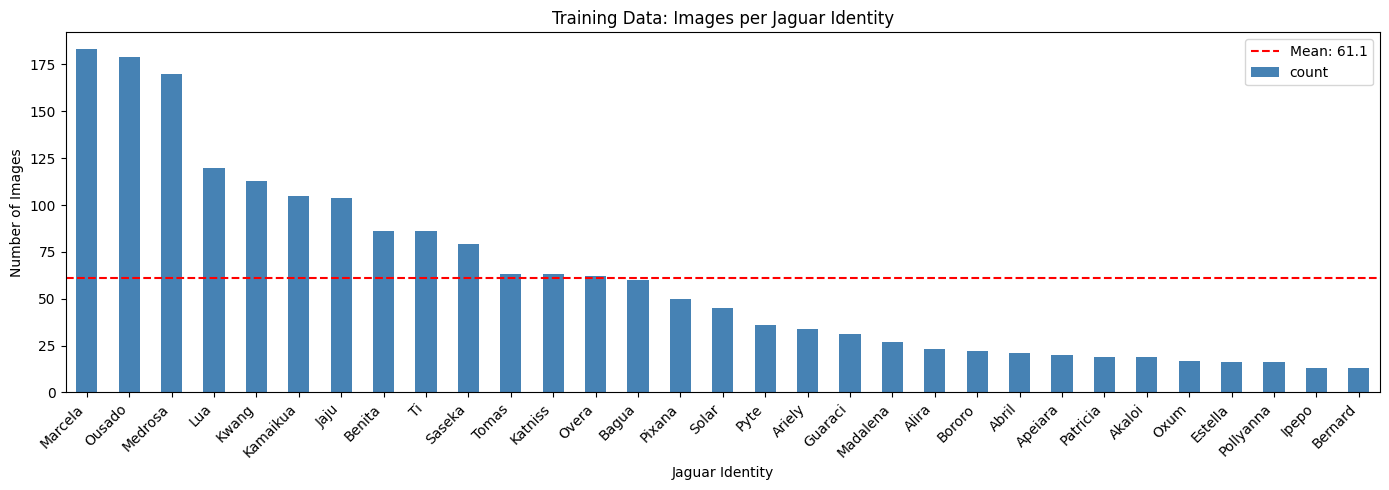

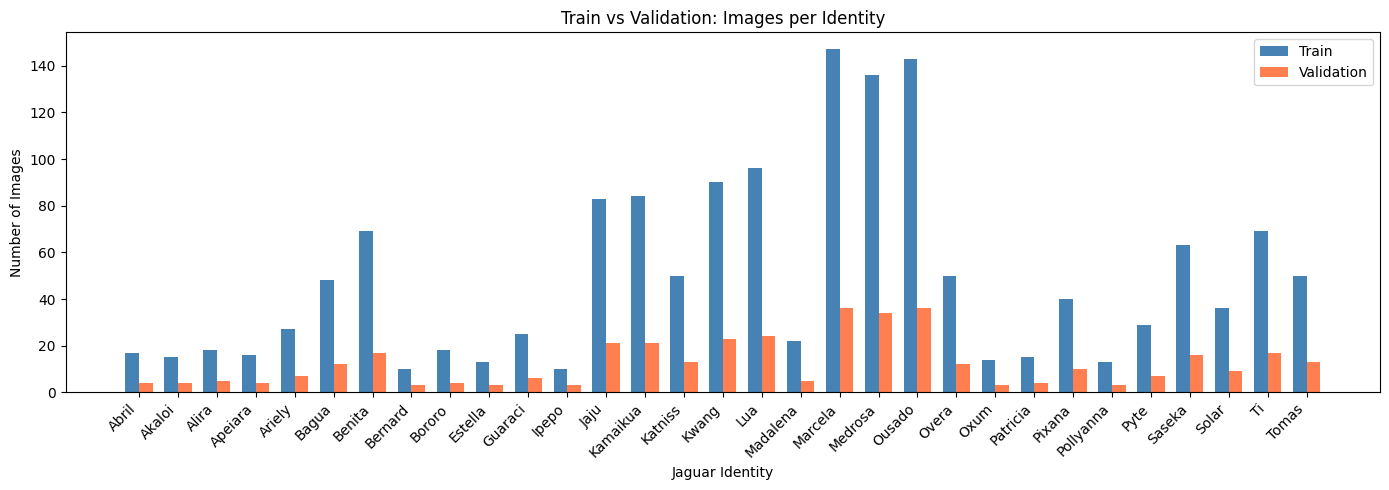


Logged identity distributions to W&B
  Train samples per identity: 10 - 147 (mean: 48.9)
  Val samples per identity: 3 - 36 (mean: 12.2)


In [2]:
# Load training data
train_df = pd.read_csv(config["data_dir"] / "train.csv")

print(f"Training dataset:")
print(f"  Total images: {len(train_df)}")
print(f"  Unique identities: {train_df['ground_truth'].nunique()}")
print(f"\nSample rows:")
print(train_df.head())

# Analyze identity distribution
identity_counts = train_df['ground_truth'].value_counts()
print(f"\nIdentity distribution:")
print(f"  Min images per identity: {identity_counts.min()} ({identity_counts.idxmin()})")
print(f"  Max images per identity: {identity_counts.max()} ({identity_counts.idxmax()})")
print(f"  Mean images per identity: {identity_counts.mean():.1f}")

# Visualize identity distribution and log to W&B
fig, ax = plt.subplots(figsize=(14, 5))
identity_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Jaguar Identity')
ax.set_ylabel('Number of Images')
ax.set_title('Training Data: Images per Jaguar Identity')
ax.axhline(y=identity_counts.mean(), color='red', linestyle='--', label=f'Mean: {identity_counts.mean():.1f}')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Log to W&B
wandb.log({"identity_distribution_full": wandb.Image(fig)})# Create stratified train/validation split
# This ensures all identities appear in both sets

# Encode labels to integers
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['ground_truth'])
num_classes = len(label_encoder.classes_)

# Stratified split: each identity's images are split proportionally
train_data, val_data = train_test_split(
    train_df,
    test_size=config["val_split"],
    random_state=config["seed"],
    stratify=train_df['ground_truth']  # Ensures proportional representation
)

print(f"Dataset split:")
print(f"  Training:   {len(train_data)} images ({100*(1-config['val_split']):.0f}%)")
print(f"  Validation: {len(val_data)} images ({100*config['val_split']:.0f}%)")

# Verify all identities are in both sets
train_identities = set(train_data['ground_truth'].unique())
val_identities = set(val_data['ground_truth'].unique())

print(f"\nIdentity coverage:")
print(f"  Identities in training:   {len(train_identities)}")
print(f"  Identities in validation: {len(val_identities)}")
print(f"  Overlap: {len(train_identities & val_identities)}")

if train_identities == val_identities:
    print("  All identities present in both sets")

# Log identity distributions to W&B
train_counts = train_data['ground_truth'].value_counts().sort_index()
val_counts = val_data['ground_truth'].value_counts().sort_index()

# Create a comparison table for W&B
distribution_df = pd.DataFrame({
    'identity': train_counts.index,
    'train_count': train_counts.values,
    'val_count': val_counts.values,
    'total_count': train_counts.values + val_counts.values,
    'train_ratio': train_counts.values / (train_counts.values + val_counts.values)
})

# Log table and summary stats to W&B
wandb.log({
    "identity_distribution_table": wandb.Table(dataframe=distribution_df),
    "num_identities": num_classes,
    "train_samples": len(train_data),
    "val_samples": len(val_data),
    "train_samples_per_identity": wandb.Histogram(train_counts.values),
    "val_samples_per_identity": wandb.Histogram(val_counts.values),
})

# Visualize train vs val distribution
fig, ax = plt.subplots(figsize=(14, 5))
width = 0.35
x = np.arange(len(train_counts))
ax.bar(x - width/2, train_counts.values, width, label='Train', color='steelblue')
ax.bar(x + width/2, val_counts.values, width, label='Validation', color='coral')
ax.set_xlabel('Jaguar Identity')
ax.set_ylabel('Number of Images')
ax.set_title('Train vs Validation: Images per Identity')
ax.set_xticks(x)
ax.set_xticklabels(train_counts.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
wandb.log({"train_val_distribution": wandb.Image(fig)})
plt.show()

print(f"\nLogged identity distributions to W&B")
print(f"  Train samples per identity: {train_counts.min()} - {train_counts.max()} (mean: {train_counts.mean():.1f})")
print(f"  Val samples per identity: {val_counts.min()} - {val_counts.max()} (mean: {val_counts.mean():.1f})")
plt.show()

# Identify identities that may need careful handling (few samples)
min_samples_for_split = 2  # Need at least 2 to split
low_sample_identities = identity_counts[identity_counts < min_samples_for_split]

if len(low_sample_identities) > 0:   
    print(f"\nWarning: {len(low_sample_identities)} identities have fewer than {min_samples_for_split} images")

Dataset split:
  Training:   1516 images (80%)
  Validation: 379 images (20%)

Identity coverage:
  Identities in training:   31
  Identities in validation: 31
  Overlap: 31
  All identities present in both sets


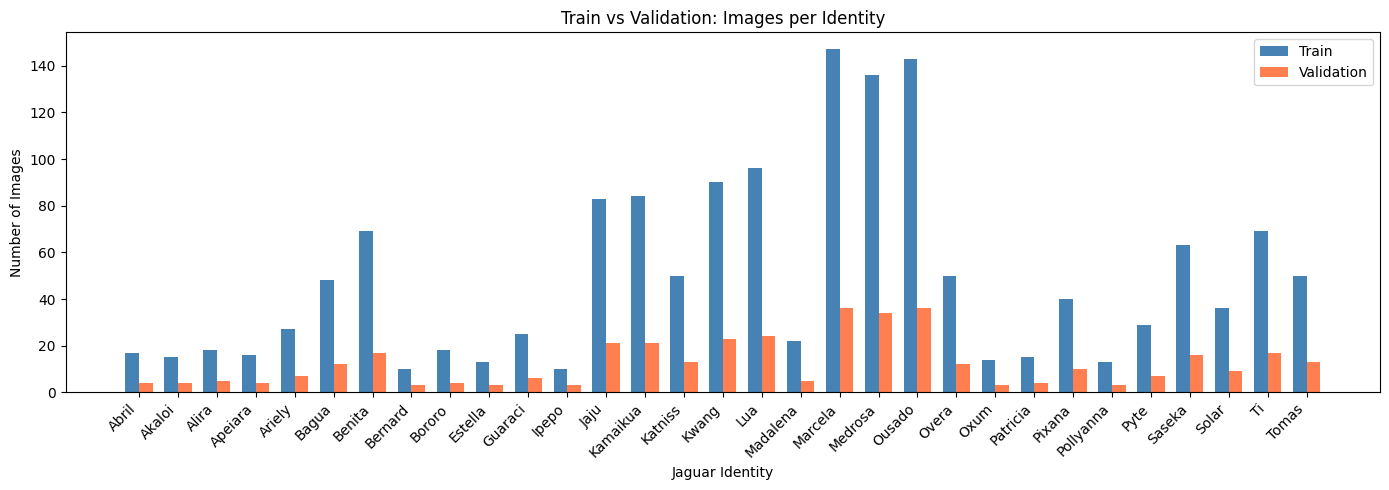


Logged identity distributions to W&B
  Train samples per identity: 10 - 147 (mean: 48.9)
  Val samples per identity: 3 - 36 (mean: 12.2)


In [3]:
# Create stratified train/validation split
# This ensures all identities appear in both sets

# Encode labels to integers
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['ground_truth'])
num_classes = len(label_encoder.classes_)

# Stratified split: each identity's images are split proportionally
train_data, val_data = train_test_split(
    train_df,
    test_size=config["val_split"],
    random_state=config["seed"],
    stratify=train_df['ground_truth']  # Ensures proportional representation
)

print(f"Dataset split:")
print(f"  Training:   {len(train_data)} images ({100*(1-config['val_split']):.0f}%)")
print(f"  Validation: {len(val_data)} images ({100*config['val_split']:.0f}%)")

# Verify all identities are in both sets
train_identities = set(train_data['ground_truth'].unique())
val_identities = set(val_data['ground_truth'].unique())

print(f"\nIdentity coverage:")
print(f"  Identities in training:   {len(train_identities)}")
print(f"  Identities in validation: {len(val_identities)}")
print(f"  Overlap: {len(train_identities & val_identities)}")

if train_identities == val_identities:
    print("  All identities present in both sets")

# Log identity distributions to W&B
train_counts = train_data['ground_truth'].value_counts().sort_index()
val_counts = val_data['ground_truth'].value_counts().sort_index()

# Create a comparison table for W&B
distribution_df = pd.DataFrame({
    'identity': train_counts.index,
    'train_count': train_counts.values,
    'val_count': val_counts.values,
    'total_count': train_counts.values + val_counts.values,
    'train_ratio': train_counts.values / (train_counts.values + val_counts.values)
})

# Log table and summary stats to W&B
wandb.log({
    "identity_distribution_table": wandb.Table(dataframe=distribution_df),
    "num_identities": num_classes,
    "train_samples": len(train_data),
    "val_samples": len(val_data),
    "train_samples_per_identity": wandb.Histogram(train_counts.values),
    "val_samples_per_identity": wandb.Histogram(val_counts.values),
})

# Visualize train vs val distribution
fig, ax = plt.subplots(figsize=(14, 5))
width = 0.35
x = np.arange(len(train_counts))
ax.bar(x - width/2, train_counts.values, width, label='Train', color='steelblue')
ax.bar(x + width/2, val_counts.values, width, label='Validation', color='coral')
ax.set_xlabel('Jaguar Identity')
ax.set_ylabel('Number of Images')
ax.set_title('Train vs Validation: Images per Identity')
ax.set_xticks(x)
ax.set_xticklabels(train_counts.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
wandb.log({"train_val_distribution": wandb.Image(fig)})
plt.show()

print(f"\nLogged identity distributions to W&B")
print(f"  Train samples per identity: {train_counts.min()} - {train_counts.max()} (mean: {train_counts.mean():.1f})")
print(f"  Val samples per identity: {val_counts.min()} - {val_counts.max()} (mean: {val_counts.mean():.1f})")

## 3. Load MegaDescriptor Model (Partial Fine-tuning)

MegaDescriptor is a **Swin Transformer** with 4 stages (24 blocks total):
- Stage 0: 2 blocks, ~0.9M params (low-level features)
- Stage 1: 2 blocks, ~3.9M params (mid-level features)
- Stage 2: 18 blocks, ~129M params (high-level features)
- Stage 3: 2 blocks, ~61M params (final features)

We unfreeze only the **last 2 blocks** (= Stage 3) + final LayerNorm.
The `unfreeze_blocks` config parameter controls exactly how many blocks from the tail end are trainable — increase it to unfreeze more, decrease to unfreeze less.

In [4]:
# Load MegaDescriptor model
print("Loading MegaDescriptor-L-384 model...")
megadescriptor = timm.create_model(
    config["megadescriptor_model"],
    pretrained=True
)
megadescriptor.to(device)

total_params = sum(p.numel() for p in megadescriptor.parameters())
print(f"Model loaded successfully")
print(f"  Type: {type(megadescriptor).__name__}")
print(f"  Total parameters: {total_params:,}")

# Get the embedding dimension from the model
with torch.no_grad():
    megadescriptor.eval()
    dummy_input = torch.randn(1, 3, config["input_size"], config["input_size"]).to(device)
    dummy_output = megadescriptor(dummy_input)
    megadescriptor_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {megadescriptor_dim}")

# --- Partial Freezing Strategy for Swin Transformer ---
# Swin Transformer has: patch_embed -> layers (4 stages) -> norm -> head
# Each stage (SwinTransformerStage) has: downsample + blocks
#
# We unfreeze exactly `unfreeze_blocks` blocks counting from the END of
# the entire model (across stages), plus the final LayerNorm.

# Print architecture overview
all_blocks = []  # (stage_idx, block_idx, block_module)
print(f"\nSwin Transformer stages:")
for i, layer in enumerate(megadescriptor.layers):
    num_params = sum(p.numel() for p in layer.parameters())
    num_blocks = len(layer.blocks) if hasattr(layer, 'blocks') else 0
    print(f"  Stage {i}: {num_blocks} blocks, {num_params:,} params")
    if hasattr(layer, 'blocks'):
        for j, block in enumerate(layer.blocks):
            all_blocks.append((i, j, block))

print(f"\n  Total blocks across all stages: {len(all_blocks)}")

# Step 1: Freeze ALL parameters
for param in megadescriptor.parameters():
    param.requires_grad = False

# Step 2: Unfreeze the last N blocks (counting from the end across all stages)
blocks_to_unfreeze = min(config["unfreeze_blocks"], len(all_blocks))
unfrozen_blocks = all_blocks[-blocks_to_unfreeze:] if blocks_to_unfreeze > 0 else []

for stage_idx, block_idx, block in unfrozen_blocks:
    for param in block.parameters():
        param.requires_grad = True
    block_params = sum(p.numel() for p in block.parameters())
    print(f"  Unfreezing stage {stage_idx}, block {block_idx} ({block_params:,} params)")

# Step 3: Unfreeze the final LayerNorm
if hasattr(megadescriptor, 'norm'):
    for param in megadescriptor.norm.parameters():
        param.requires_grad = True
    print("  Unfreezing final LayerNorm")

# Summary
trainable_params = sum(p.numel() for p in megadescriptor.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params
print(f"\n  Backbone trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")
print(f"  Backbone frozen parameters:   {frozen_params:,} ({100*frozen_params/total_params:.1f}%)")

# Log to W&B
wandb.log({
    "backbone_total_params": total_params,
    "backbone_trainable_params": trainable_params,
    "backbone_frozen_params": frozen_params,
})

# Set backbone to training mode (needed for unfrozen LayerNorm)
megadescriptor.train()

# Define preprocessing pipeline
# Same as baseline: Resize + ToTensor + ImageNet Normalize (no augmentation)
preprocess = transforms.Compose([
    transforms.Resize((config["input_size"], config["input_size"])),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

print("\nPreprocessing pipeline configured:")
print(f"  Resize to: {config['input_size']}x{config['input_size']}")
print(f"  Normalization: ImageNet statistics")


@torch.no_grad()
def extract_embeddings(model, image_paths, batch_size=32, desc="Extracting embeddings"):
    """
    Extract feature embeddings for a list of images using a pretrained model.
    """
    model.eval()
    embeddings = []
    
    for i in tqdm(range(0, len(image_paths), batch_size), desc=desc):
        batch_paths = image_paths[i:i + batch_size]
        
        batch_tensors = []
        for path in batch_paths:
            try:
                img = Image.open(path).convert("RGB")
                tensor = preprocess(img)
                batch_tensors.append(tensor)
            except Exception as e:
                print(f"Error loading {path}: {e}")
                batch_tensors.append(torch.zeros(3, config["input_size"], config["input_size"]))
        
        batch_tensor = torch.stack(batch_tensors).to(device)
        batch_emb = model(batch_tensor).cpu().numpy()
        embeddings.append(batch_emb)
    
    return np.vstack(embeddings)

print("Embedding extraction function defined")


Loading MegaDescriptor-L-384 model...


config.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

Model loaded successfully
  Type: SwinTransformer
  Total parameters: 195,198,516
  Embedding dimension: 1536

Swin Transformer stages:
  Stage 0: 2 blocks, 896,076 params
  Stage 1: 2 blocks, 3,858,072 params
  Stage 2: 18 blocks, 128,992,944 params
  Stage 3: 2 blocks, 61,438,560 params

  Total blocks across all stages: 24
  Unfreezing stage 3, block 0 (28,356,912 params)
  Unfreezing stage 3, block 1 (28,356,912 params)
  Unfreezing final LayerNorm

  Backbone trainable parameters: 56,716,896 (29.1%)
  Backbone frozen parameters:   138,481,620 (70.9%)

Preprocessing pipeline configured:
  Resize to: 384x384
  Normalization: ImageNet statistics
Embedding extraction function defined


In [5]:
# Extract baseline embeddings BEFORE fine-tuning (for MDS comparison)
# These capture how well MegaDescriptor separates jaguars out-of-the-box

train_filenames = train_data["filename"].astype(str).tolist()
train_image_paths = [config["data_dir"] / "train" / fn for fn in train_filenames]
val_image_paths = [config["data_dir"] / "train" / fn for fn in val_data['filename'].values]

print(f"Extracting baseline embeddings for {len(train_image_paths)} training images...")
baseline_train_embeddings = extract_embeddings(
    megadescriptor,
    train_image_paths,
    batch_size=config["batch_size"],
    desc="Baseline train embeddings"
)
print(f"Baseline train embeddings shape: {baseline_train_embeddings.shape}")

print(f"\nExtracting baseline embeddings for {len(val_image_paths)} validation images...")
baseline_val_embeddings = extract_embeddings(
    megadescriptor,
    val_image_paths,
    batch_size=config["batch_size"],
    desc="Baseline val embeddings"
)
print(f"Baseline val embeddings shape: {baseline_val_embeddings.shape}")


Extracting baseline embeddings for 1516 training images...


Baseline train embeddings:   0%|          | 0/95 [00:00<?, ?it/s]

Baseline train embeddings shape: (1516, 1536)

Extracting baseline embeddings for 379 validation images...


Baseline val embeddings:   0%|          | 0/24 [00:00<?, ?it/s]

Baseline val embeddings shape: (379, 1536)


## 4. Visualize Baseline Embeddings with MDS

Multidimensional Scaling (MDS) projects high-dimensional embeddings to 2D while preserving pairwise distances. For embeddings on a hypersphere (L2-normalized), we use geodesic distances (arc length) rather than Euclidean distances.

This visualization shows how well MegaDescriptor separates different jaguars before any fine-tuning.

MDS visualization functions defined


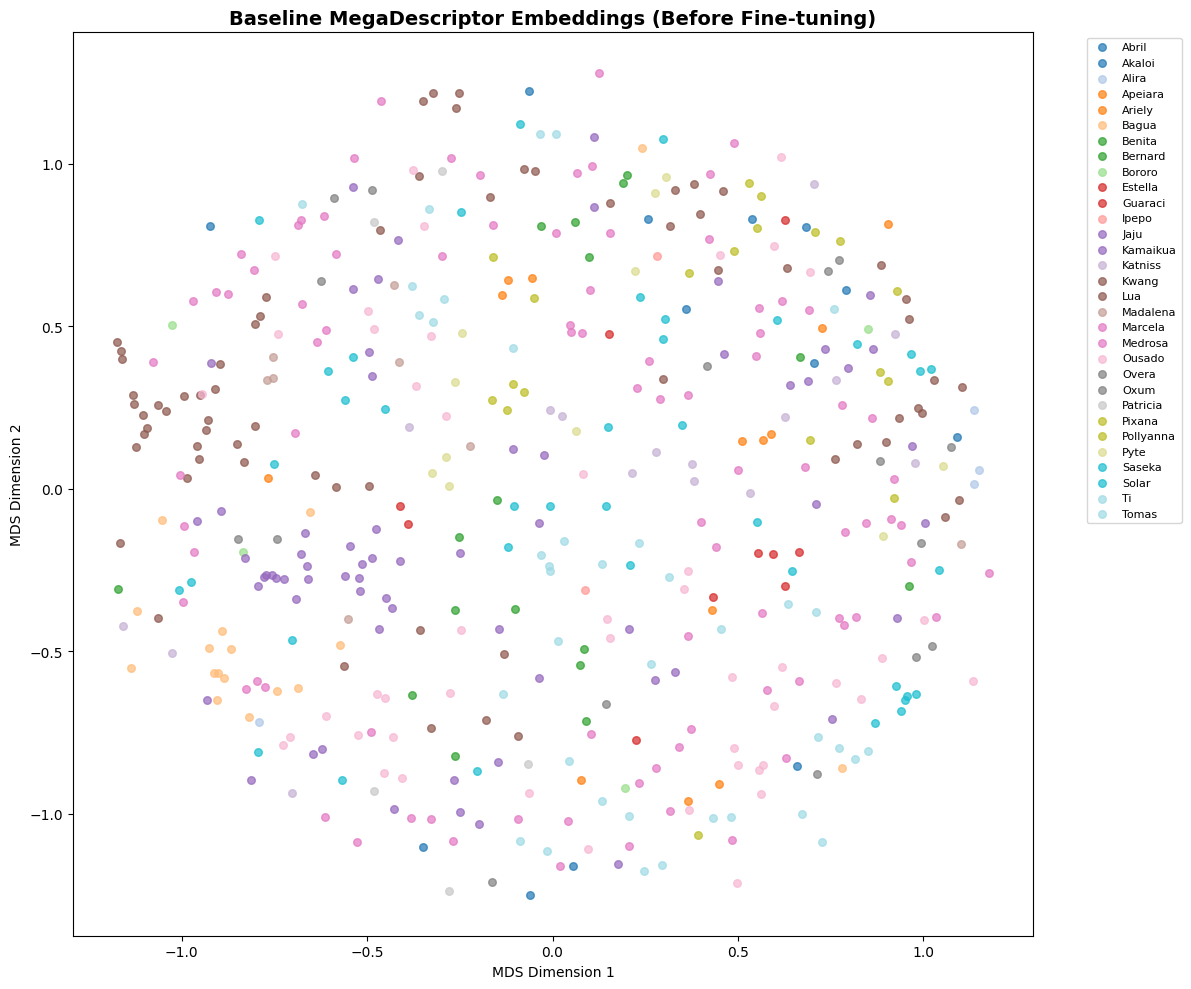

In [6]:
def compute_geodesic_distances(embeddings):
    """Compute geodesic (angular) distance matrix for normalized embeddings."""
    # Normalize embeddings to unit sphere
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    normalized = embeddings / norms
    
    # Compute cosine similarity
    cos_sim = np.clip(normalized @ normalized.T, -1.0, 1.0)
    
    # Convert to geodesic distance (arc length)
    geodesic_dist = np.arccos(cos_sim)
    
    return geodesic_dist


def visualize_embeddings_mds(embeddings, labels, title, max_samples=500):
    """Visualize embeddings using MDS with geodesic distances."""
    # Subsample if too many points (MDS is O(n^3))
    if len(embeddings) > max_samples:
        indices = np.random.choice(len(embeddings), max_samples, replace=False)
        embeddings = embeddings[indices]
        labels = labels[indices]
    
    # Compute geodesic distance matrix
    dist_matrix = compute_geodesic_distances(embeddings)
    
    # Apply MDS
    mds = MDS(n_components=2, dissimilarity='precomputed', random_state=RANDOM_SEED, normalized_stress='auto')
    coords_2d = mds.fit_transform(dist_matrix)
    
    # Create color mapping for identities
    unique_labels = np.unique(labels)
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
    label_to_color = {label: colors[i] for i, label in enumerate(unique_labels)}
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 10))
    
    for label in unique_labels:
        mask = labels == label
        ax.scatter(
            coords_2d[mask, 0], 
            coords_2d[mask, 1],
            c=[label_to_color[label]],
            label=label,
            alpha=0.7,
            s=30
        )
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('MDS Dimension 1')
    ax.set_ylabel('MDS Dimension 2')
    
    # Legend outside plot
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    
    return fig

print("MDS visualization functions defined")


# Visualize baseline embeddings
train_labels = train_data['ground_truth'].values

fig_baseline = visualize_embeddings_mds(
    baseline_train_embeddings,
    train_labels,
    "Baseline MegaDescriptor Embeddings (Before Fine-tuning)"
)
plt.show()

# Log to W&B
wandb.log({"baseline_embeddings_mds": wandb.Image(fig_baseline)})

## 5. Define End-to-End Model Architecture

Unlike the baseline (which trains only on pre-computed embeddings), this model passes images through:

1. **MegaDescriptor backbone** (last 2 blocks unfrozen): Extracts 1536-dim features, with the final layers adapting to jaguar-specific patterns
2. **EmbeddingProjection**: Projects 1536-dim → 256-dim
3. **ArcFaceLayer**: Metric learning with angular margin loss

The backbone and head use **differential learning rates** to prevent catastrophic forgetting.

In [7]:
class EmbeddingProjection(nn.Module):
    """
    Projects MegaDescriptor embeddings to a lower-dimensional space.
    Architecture: input_dim -> hidden_dim -> output_dim
    """
    
    def __init__(self, input_dim=1536, hidden_dim=512, output_dim=256, dropout=0.3):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_dim, output_dim),
            nn.BatchNorm1d(output_dim),
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        return self.network(x)


class ArcFaceLayer(nn.Module):
    """
    ArcFace (Additive Angular Margin Loss) layer.
    """
    
    def __init__(self, embedding_dim, num_classes, margin=0.5, scale=64.0):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_classes = num_classes
        self.margin = margin
        self.scale = scale
        
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)
        
        self.cos_m = math.cos(margin)
        self.sin_m = math.sin(margin)
        self.th = math.cos(math.pi - margin)
        self.mm = math.sin(math.pi - margin) * margin
    
    def forward(self, embeddings, labels):
        embeddings = F.normalize(embeddings, p=2, dim=1)
        weight_norm = F.normalize(self.weight, p=2, dim=1)
        
        cosine = F.linear(embeddings, weight_norm)
        cosine = cosine.clamp(-1.0, 1.0)
        
        sine = torch.sqrt(1.0 - torch.pow(cosine, 2))
        phi = cosine * self.cos_m - sine * self.sin_m
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)
        
        one_hot = torch.zeros(cosine.size(), device=embeddings.device)
        one_hot.scatter_(1, labels.view(-1, 1).long(), 1)
        
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        output = output * self.scale
        
        return output


class EndToEndArcFaceModel(nn.Module):
    """
    End-to-end model: MegaDescriptor backbone + Embedding Projection + ArcFace.
    
    Unlike the baseline ArcFaceModel (which operates on pre-computed embeddings),
    this model takes raw images as input and passes them through the backbone.
    """
    
    def __init__(self, backbone, input_dim, num_classes, embedding_dim=256, 
                 hidden_dim=512, margin=0.5, scale=64.0, dropout=0.3):
        super().__init__()
        self.backbone = backbone  # MegaDescriptor (partially frozen)
        self.embedding_net = EmbeddingProjection(
            input_dim=input_dim, 
            hidden_dim=hidden_dim,
            output_dim=embedding_dim,
            dropout=dropout
        )
        self.arcface = ArcFaceLayer(
            embedding_dim=embedding_dim, 
            num_classes=num_classes,
            margin=margin, 
            scale=scale
        )
    
    def forward(self, images, labels):
        """Forward pass for training: images -> backbone -> projection -> ArcFace."""
        features = self.backbone(images)          # (B, 1536)
        embeddings = self.embedding_net(features)  # (B, 256)
        logits = self.arcface(embeddings, labels)  # (B, num_classes)
        return logits, embeddings
    
    def get_embeddings(self, images):
        """Get normalized embeddings for inference."""
        features = self.backbone(images)
        embeddings = self.embedding_net(features)
        return F.normalize(embeddings, p=2, dim=1)
    
    def get_backbone_features(self, images):
        """Get raw backbone features (for comparison with baseline)."""
        return self.backbone(images)


# Create end-to-end model
model = EndToEndArcFaceModel(
    backbone=megadescriptor,
    input_dim=megadescriptor_dim,
    num_classes=num_classes,
    embedding_dim=config["embedding_dim"],
    hidden_dim=config["hidden_dim"],
    margin=config["arcface_margin"],
    dropout=config["dropout"],
).to(device)

# Count parameters
backbone_trainable = sum(p.numel() for p in model.backbone.parameters() if p.requires_grad)
head_trainable = sum(p.numel() for p in model.embedding_net.parameters() if p.requires_grad) + \
                 sum(p.numel() for p in model.arcface.parameters() if p.requires_grad)
total_trainable = backbone_trainable + head_trainable

print(f"End-to-End ArcFace Model:")
print(f"  Backbone (MegaDescriptor):")
print(f"    Trainable: {backbone_trainable:,} (last {config['unfreeze_blocks']} blocks + norm)")
print(f"    LR: {config['backbone_lr']}")
print(f"  Head (Projection + ArcFace):")
print(f"    Trainable: {head_trainable:,}")
print(f"    LR: {config['learning_rate']}")
print(f"  Total trainable: {total_trainable:,}")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  ArcFace margin: {config['arcface_margin']}")
print(f"  ArcFace scale: {config['arcface_scale']}")


End-to-End ArcFace Model:
  Backbone (MegaDescriptor):
    Trainable: 56,716,896 (last 2 blocks + norm)
    LR: 1e-05
  Head (Projection + ArcFace):
    Trainable: 927,744
    LR: 0.0001
  Total trainable: 57,644,640
  Embedding dim: 256
  ArcFace margin: 0.5
  ArcFace scale: 64.0


## 6. Prepare Image DataLoaders

Unlike the baseline (which uses pre-computed embedding datasets), we load actual images since the backbone is being fine-tuned. Training data uses augmentation; validation data does not.

In [8]:
# (Baseline val embeddings already extracted above for mAP computation)
# No separate extraction needed here — we use the image-based DataLoader for training
print(f"Baseline val embeddings available: {baseline_val_embeddings.shape}")


Baseline val embeddings available: (379, 1536)


In [9]:
class JaguarImageDataset(Dataset):
    """PyTorch Dataset that loads images from disk for end-to-end training."""
    
    def __init__(self, dataframe, data_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.data_dir = data_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_path = self.data_dir / "train" / row['filename']
        
        try:
            img = Image.open(img_path).convert("RGB")
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            img = Image.new("RGB", (config["input_size"], config["input_size"]))
        
        if self.transform:
            img = self.transform(img)
        
        label = torch.tensor(row['label_encoded'], dtype=torch.long)
        return img, label


# Create datasets (same preprocessing for train and val, matching baseline)
train_dataset = JaguarImageDataset(
    train_data, 
    config["data_dir"], 
    transform=preprocess
)
val_dataset = JaguarImageDataset(
    val_data, 
    config["data_dir"], 
    transform=preprocess
)

# Create dataloaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=config["batch_size"], 
    shuffle=True,
    num_workers=2,
    pin_memory=(device.type == "cuda"),
    drop_last=True  # Drop last incomplete batch (important for BatchNorm)
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=config["batch_size"], 
    shuffle=False,
    num_workers=2,
    pin_memory=(device.type == "cuda"),
)

print(f"Image DataLoaders created:")
print(f"  Train: {len(train_dataset)} images, {len(train_loader)} batches")
print(f"  Val:   {len(val_dataset)} images, {len(val_loader)} batches")
print(f"  Batch size: {config['batch_size']}")


Image DataLoaders created:
  Train: 1516 images, 94 batches
  Val:   379 images, 24 batches
  Batch size: 16


## 7. Training Setup (Differential Learning Rates)

Key differences from baseline:
- **Two parameter groups** with different learning rates:
  - Backbone (unfrozen blocks): `1e-5` — slow adaptation to prevent catastrophic forgetting
  - Head (projection + ArcFace): `1e-4` — faster learning for task-specific layers
- Training and validation epochs now process **images** (not pre-computed embeddings)
- Validation mAP is computed by extracting embeddings through the full model pipeline

In [10]:
def compute_validation_map(model, val_loader, val_labels, label_encoder, device):
    """
    Compute identity-balanced mean Average Precision on the validation set.
    
    Unlike the baseline, this extracts embeddings through the full end-to-end model
    (backbone + projection) rather than using pre-computed embeddings.
    """
    model.eval()
    
    all_embeddings = []
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            emb = model.get_embeddings(images).cpu().numpy()
            all_embeddings.append(emb)
    
    finetuned_emb = np.vstack(all_embeddings)
    
    # Compute cosine similarity matrix
    sim_matrix = cosine_similarity(finetuned_emb)
    np.fill_diagonal(sim_matrix, -1)
    
    # Compute AP for each query
    query_aps = {}
    
    for query_idx in range(len(val_labels)):
        query_label = val_labels[query_idx]
        
        similarities = sim_matrix[query_idx]
        gallery_labels = val_labels.copy()
        is_match = (gallery_labels == query_label).astype(int)
        is_match[query_idx] = 0
        
        sorted_indices = np.argsort(-similarities)
        sorted_matches = is_match[sorted_indices]
        
        n_positives = sorted_matches.sum()
        if n_positives == 0:
            continue
        
        cumsum = np.cumsum(sorted_matches)
        precision_at_k = cumsum / np.arange(1, len(sorted_matches) + 1)
        ap = np.sum(precision_at_k * sorted_matches) / n_positives
        
        query_aps[query_idx] = (query_label, ap)
    
    # Group by identity and compute identity-balanced mAP
    identity_aps = {}
    for query_idx, (label, ap) in query_aps.items():
        if label not in identity_aps:
            identity_aps[label] = []
        identity_aps[label].append(ap)
    
    identity_mean_aps = [np.mean(aps) for aps in identity_aps.values()]
    balanced_map = np.mean(identity_mean_aps)
    
    return balanced_map


print("Validation mAP function defined")

# --- Setup optimizer with differential learning rates ---

# Collect backbone parameters (only unfrozen ones)
backbone_params = [p for p in model.backbone.parameters() if p.requires_grad]

# Collect head parameters (projection + ArcFace)
head_params = list(model.embedding_net.parameters()) + list(model.arcface.parameters())

optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": config["backbone_lr"], "weight_decay": config["weight_decay"]},
    {"params": head_params, "lr": config["learning_rate"], "weight_decay": config["weight_decay"]},
])

criterion = nn.CrossEntropyLoss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,
)

print("Training components initialized:")
print(f"  Loss: CrossEntropyLoss")
print(f"  Optimizer: AdamW with 2 param groups")
print(f"    Group 0 (backbone): lr={config['backbone_lr']}, {len(backbone_params)} tensors")
print(f"    Group 1 (head):     lr={config['learning_rate']}, {len(head_params)} tensors")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")


def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch with image inputs."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc='Training', leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass through full pipeline (backbone + head)
        logits, _ = model(images, labels)
        loss = criterion(logits, labels)
        
        # Backward pass (gradients flow into unfrozen backbone layers)
        optimizer.zero_grad()
        loss.backward()
        
        # Gradient clipping for backbone stability
        torch.nn.utils.clip_grad_norm_(model.backbone.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        # Metrics
        total_loss += loss.item()
        _, predicted = torch.max(logits.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100.*correct/total:.1f}%'})
    
    avg_loss = total_loss / len(loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy


def validate_epoch(model, loader, criterion, device):
    """Validate for one epoch with image inputs."""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        pbar = tqdm(loader, desc='Validation', leave=False)
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            
            logits, _ = model(images, labels)
            loss = criterion(logits, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100.*correct/total:.1f}%'})
    
    avg_loss = total_loss / len(loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy


print("Training and validation functions defined")


Validation mAP function defined
Training components initialized:
  Loss: CrossEntropyLoss
  Optimizer: AdamW with 2 param groups
    Group 0 (backbone): lr=1e-05, 28 tensors
    Group 1 (head):     lr=0.0001, 9 tensors
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)
Training and validation functions defined


## 8. Training Loop

Same structure as baseline but:
- Each epoch processes **images** through the full pipeline (slower but updates backbone)
- Checkpoint saves the **entire model** including backbone state
- Logs both backbone and head learning rates

In [11]:
# Training loop
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [],
    'val_map': [], 'backbone_lr': [], 'head_lr': []
}

best_val_loss = float('inf')
best_map = 0.0
patience_counter = 0
best_epoch = 0

print(f"Starting training for {config['num_epochs']} epochs...")
print(f"  Backbone LR: {config['backbone_lr']} | Head LR: {config['learning_rate']}")
print("=" * 70)

for epoch in range(config['num_epochs']):
    print(f"\nEpoch {epoch+1}/{config['num_epochs']}")
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    
    # Compute validation mAP (using image-based extraction)
    val_map = compute_validation_map(
        model, 
        val_loader,
        val_data['ground_truth'].values,
        label_encoder,
        device
    )
    
    # Update scheduler
    scheduler.step(val_loss)
    backbone_lr = optimizer.param_groups[0]['lr']
    head_lr = optimizer.param_groups[1]['lr']
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_map'].append(val_map)
    history['backbone_lr'].append(backbone_lr)
    history['head_lr'].append(head_lr)
    
    # Log to W&B
    wandb.log({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'val_loss': val_loss,
        'val_acc': val_acc,
        'val_map': val_map,
        'backbone_lr': backbone_lr,
        'head_lr': head_lr,
    })
    
    # Print summary
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.1f}%")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.1f}%")
    print(f"  Val mAP:    {val_map:.4f}")
    print(f"  LR — Backbone: {backbone_lr:.2e} | Head: {head_lr:.2e}")
    
    # Checkpoint best model (saves entire model including backbone)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_map = val_map
        best_epoch = epoch + 1
        patience_counter = 0
        
        checkpoint_path = config["checkpoint_dir"] / "finetune_backbone_best.pth"
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_map': val_map,
            'config': config,
            'label_encoder_classes': label_encoder.classes_.tolist(),
            'num_classes': num_classes,
        }, checkpoint_path)
        
        print(f"  [New best model saved]")
    else:
        patience_counter += 1
        print(f"  No improvement. Patience: {patience_counter}/{config['patience']}")
    
    # Early stopping
    if patience_counter >= config['patience']:
        print(f"\nEarly stopping triggered after {epoch+1} epochs")
        break

print("\n" + "=" * 70)
print(f"Training complete!")
print(f"Best epoch: {best_epoch} (Val Loss: {best_val_loss:.4f}, Val mAP: {best_map:.4f})")

# Log best metrics
wandb.run.summary["best_val_mAP"] = best_map
wandb.run.summary["best_val_loss"] = best_val_loss
wandb.run.summary["best_epoch"] = best_epoch
wandb.run.summary["total_epochs"] = len(history['train_loss'])


Starting training for 50 epochs...
  Backbone LR: 1e-05 | Head LR: 0.0001

Epoch 1/50


Training:   0%|          | 0/94 [00:00<?, ?it/s]

Validation:   0%|          | 0/24 [00:00<?, ?it/s]

  Train Loss: 36.5320 | Train Acc: 0.0%
  Val Loss:   31.1358 | Val Acc:   0.0%
  Val mAP:    0.2771
  LR — Backbone: 1.00e-05 | Head: 1.00e-04
  [New best model saved]

Epoch 2/50


Training:   0%|          | 0/94 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/24 [00:00<?, ?it/s]

  Train Loss: 1.6041 | Train Acc: 85.2%
  Val Loss:   4.2315 | Val Acc:   86.8%
  Val mAP:    0.8372
  LR — Backbone: 1.00e-05 | Head: 1.00e-04
  No improvement. Patience: 2/10

Epoch 50/50


Training:   0%|          | 0/94 [00:00<?, ?it/s]

Validation:   0%|          | 0/24 [00:00<?, ?it/s]

  Train Loss: 1.1055 | Train Acc: 88.4%
  Val Loss:   4.3042 | Val Acc:   87.1%
  Val mAP:    0.8282
  LR — Backbone: 1.00e-05 | Head: 1.00e-04
  No improvement. Patience: 3/10

Training complete!
Best epoch: 47 (Val Loss: 4.2243, Val mAP: 0.8285)


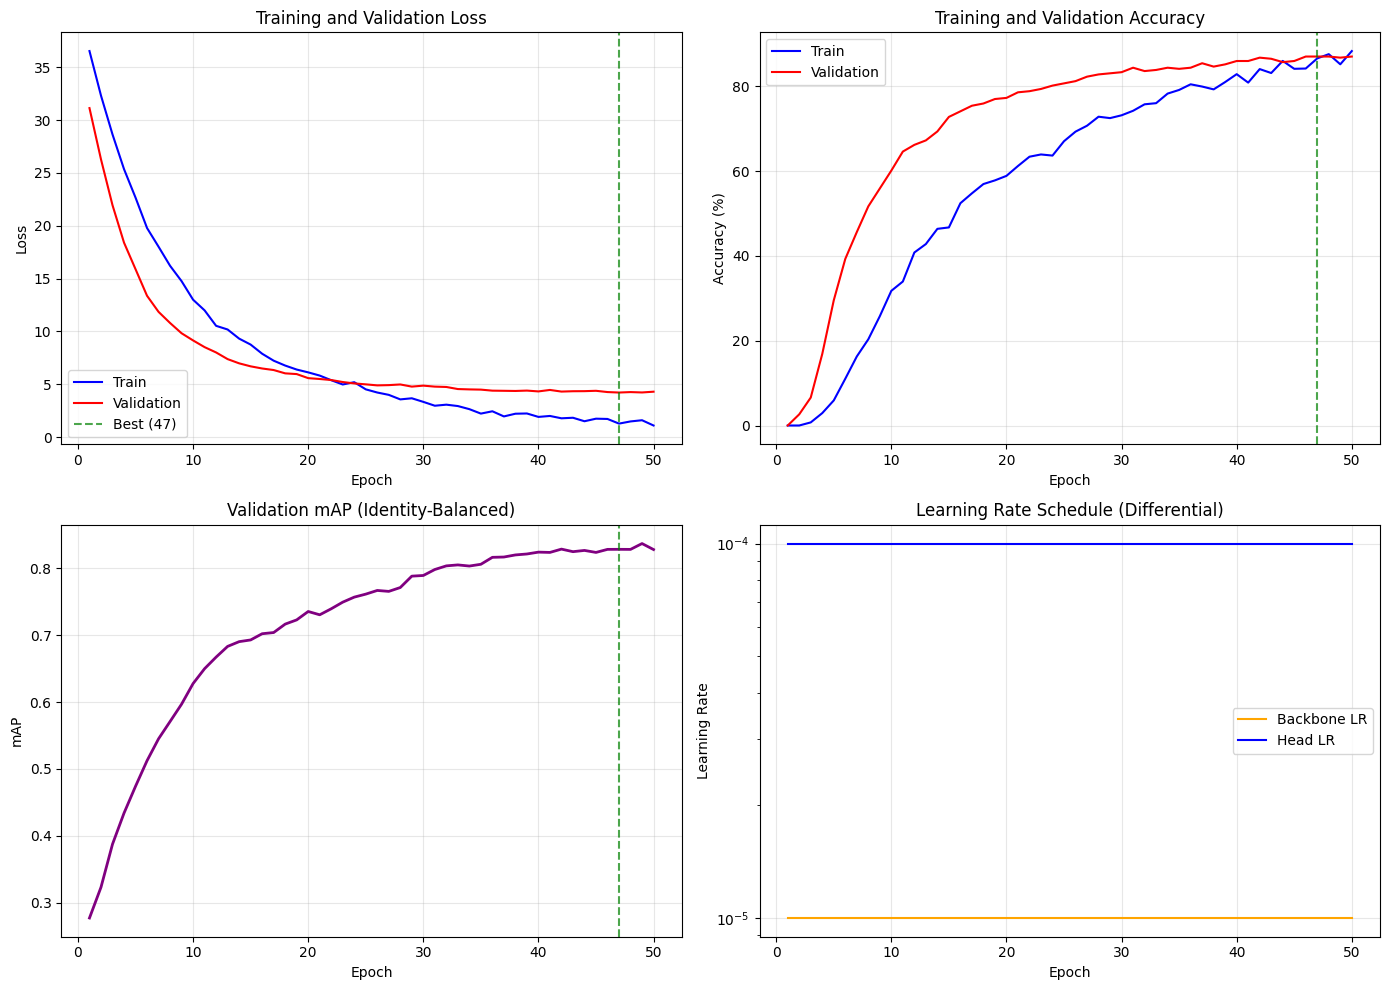

In [12]:
# Plot training curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
axes[0, 0].plot(epochs_range, history['train_loss'], 'b-', label='Train')
axes[0, 0].plot(epochs_range, history['val_loss'], 'r-', label='Validation')
axes[0, 0].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7, label=f'Best ({best_epoch})')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(epochs_range, history['train_acc'], 'b-', label='Train')
axes[0, 1].plot(epochs_range, history['val_acc'], 'r-', label='Validation')
axes[0, 1].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Training and Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# mAP
axes[1, 0].plot(epochs_range, history['val_map'], 'purple', linewidth=2)
axes[1, 0].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('mAP')
axes[1, 0].set_title('Validation mAP (Identity-Balanced)')
axes[1, 0].grid(True, alpha=0.3)

# Learning rates
axes[1, 1].plot(epochs_range, history['backbone_lr'], 'orange', label='Backbone LR')
axes[1, 1].plot(epochs_range, history['head_lr'], 'blue', label='Head LR')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_title('Learning Rate Schedule (Differential)')
axes[1, 1].set_yscale('log')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(config["checkpoint_dir"] / 'finetune_backbone_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

wandb.log({"training_curves": wandb.Image(fig)})


## 9. Visualize Fine-tuned Embeddings

After training, we visualize the fine-tuned embeddings using MDS and compare them to the baseline. We expect to see tighter clusters for each identity after ArcFace training.

In [13]:
# Load best model
checkpoint = torch.load(config["checkpoint_dir"] / "finetune_backbone_best.pth", map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {checkpoint['epoch']}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")


Loaded best model from epoch 47
  Val Loss: 4.2243
  Val mAP: 0.8285


In [14]:
# Extract fine-tuned embeddings for training data (through end-to-end model)
model.eval()

finetuned_train_embeddings = []
with torch.no_grad():
    train_eval_loader = DataLoader(
        JaguarImageDataset(train_data, config["data_dir"], transform=preprocess),
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=2,
    )
    for images, labels in tqdm(train_eval_loader, desc="Extracting fine-tuned embeddings"):
        images = images.to(device)
        emb = model.get_embeddings(images).cpu().numpy()
        finetuned_train_embeddings.append(emb)

finetuned_train_embeddings = np.vstack(finetuned_train_embeddings)

print(f"Fine-tuned embeddings shape: {finetuned_train_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_train_embeddings, axis=1).mean():.4f}")


Extracting fine-tuned embeddings:   0%|          | 0/95 [00:00<?, ?it/s]

Fine-tuned embeddings shape: (1516, 256)
Mean L2 norm: 1.0000


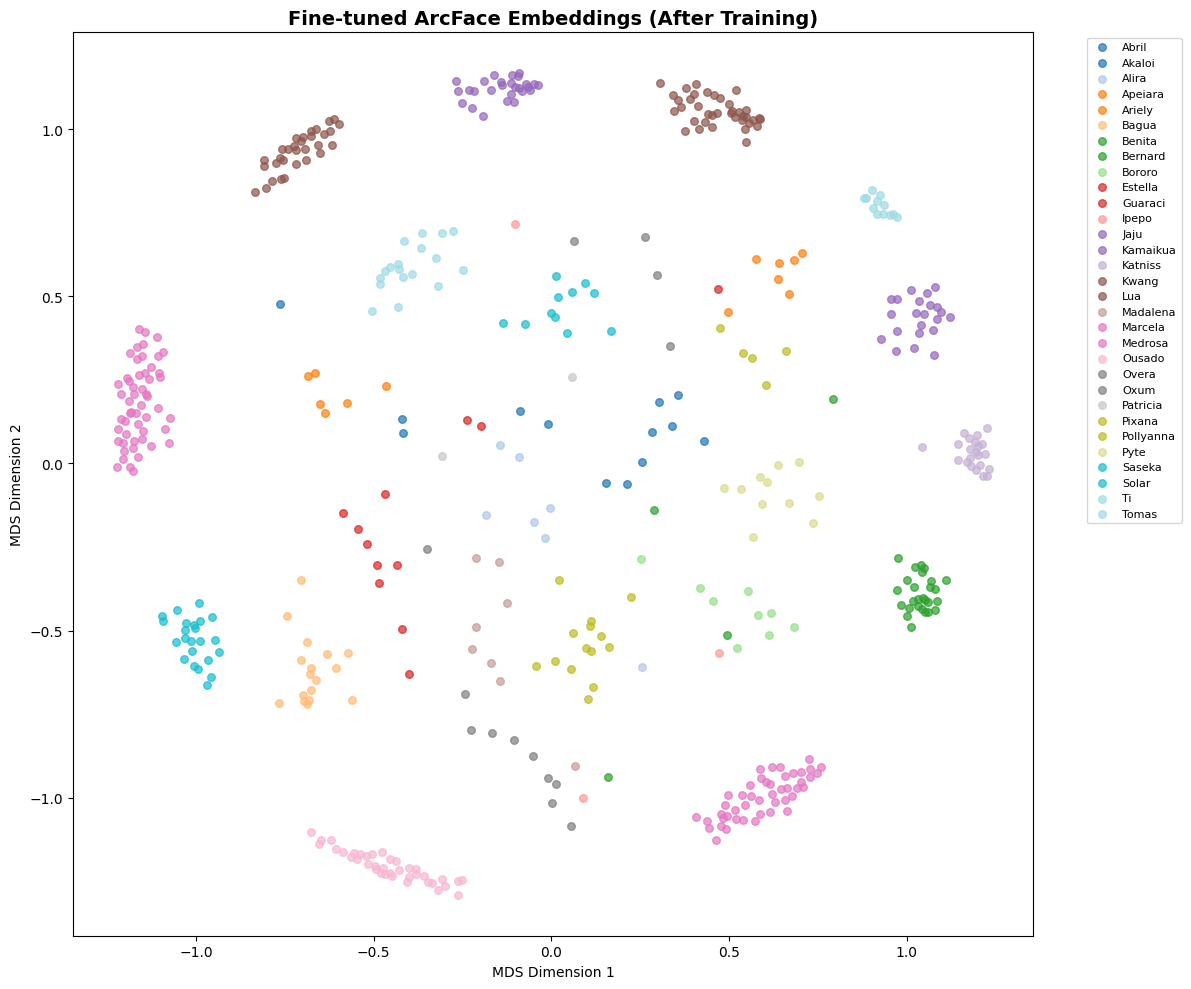

In [15]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_train_embeddings,
    train_labels,
    "Fine-tuned ArcFace Embeddings (After Training)"
)
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds": wandb.Image(fig_finetuned)})

## 10. Generate Competition Submission

Now we generate predictions for the test set. The competition expects:
- A CSV with columns: `row_id`, `similarity`
- Each row corresponds to a query-gallery image pair from `test.csv`
- `similarity` is a float between 0 and 1

We:
1. Extract embeddings for all test images through the full end-to-end model (backbone + projection)
2. Compute cosine similarity for each pair in `test.csv`
3. Clip values to [0, 1] and save as CSV


In [16]:
# Load test.csv to get the pairs we need to score
test_pairs_df = pd.read_csv(config["data_dir"] / "test.csv")

print(f"Test pairs to score: {len(test_pairs_df)}")
print(f"Columns: {list(test_pairs_df.columns)}")
print(f"\nSample rows:")
print(test_pairs_df.head())

Test pairs to score: 137270
Columns: ['row_id', 'query_image', 'gallery_image']

Sample rows:
   row_id    query_image  gallery_image
0       0  test_0001.png  test_0002.png
1       1  test_0001.png  test_0003.png
2       2  test_0001.png  test_0004.png
3       3  test_0001.png  test_0005.png
4       4  test_0001.png  test_0006.png


In [17]:
# Get unique test images and extract embeddings through the full end-to-end model
test_images = set(test_pairs_df['query_image'].unique()) | set(test_pairs_df['gallery_image'].unique())
test_images = sorted(list(test_images))

print(f"Unique test images: {len(test_images)}")

# Build paths
test_image_paths = [config["data_dir"] / "test/test" / filename for filename in test_images]

# Create a simple dataset for test images
class TestImageDataset(Dataset):
    def __init__(self, image_paths, transform):
        self.image_paths = image_paths
        self.transform = transform
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        try:
            img = Image.open(self.image_paths[idx]).convert("RGB")
        except Exception as e:
            print(f"Error loading {self.image_paths[idx]}: {e}")
            img = Image.new("RGB", (config["input_size"], config["input_size"]))
        return self.transform(img)

test_dataset = TestImageDataset(test_image_paths, preprocess)
test_loader = DataLoader(test_dataset, batch_size=config["batch_size"], shuffle=False, num_workers=2)

# Extract embeddings through the full model (backbone + projection)
model.eval()
test_embeddings = []
with torch.no_grad():
    for images in tqdm(test_loader, desc="Extracting test embeddings"):
        images = images.to(device)
        emb = model.get_embeddings(images).cpu().numpy()
        test_embeddings.append(emb)

test_embeddings = np.vstack(test_embeddings)

print(f"Test embeddings shape: {test_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(test_embeddings, axis=1).mean():.4f}")

# Create mapping from filename to embedding
img_to_embedding = {
    filename: embedding 
    for filename, embedding in zip(test_images, test_embeddings)
}

Unique test images: 371


Extracting test embeddings:   0%|          | 0/24 [00:00<?, ?it/s]

Error loading /kaggle/input/competitions/round-2-jaguar-reidentification-challenge/test/test/test_0001.png: [Errno 2] No such file or directory: '/kaggle/input/competitions/round-2-jaguar-reidentification-challenge/test/test/test_0001.png'
Error loading /kaggle/input/competitions/round-2-jaguar-reidentification-challenge/test/test/test_0017.png: [Errno 2] No such file or directory: '/kaggle/input/competitions/round-2-jaguar-reidentification-challenge/test/test/test_0017.png'
Error loading /kaggle/input/competitions/round-2-jaguar-reidentification-challenge/test/test/test_0002.png: [Errno 2] No such file or directory: '/kaggle/input/competitions/round-2-jaguar-reidentification-challenge/test/test/test_0002.png'
Error loading /kaggle/input/competitions/round-2-jaguar-reidentification-challenge/test/test/test_0003.png: [Errno 2] No such file or directory: '/kaggle/input/competitions/round-2-jaguar-reidentification-challenge/test/test/test_0003.png'Error loading /kaggle/input/competitions/

In [18]:
# Compute similarity for each pair
print("Computing pairwise similarities...")
similarities = []

for _, row in tqdm(test_pairs_df.iterrows(), total=len(test_pairs_df), desc="Computing similarities"):
    query_emb = img_to_embedding[row['query_image']]
    gallery_emb = img_to_embedding[row['gallery_image']]
    
    # Cosine similarity (embeddings are already normalized)
    sim = np.dot(query_emb, gallery_emb)
    similarities.append(sim)

# Clip to [0, 1] range
similarities = np.array(similarities)
similarities = np.clip(similarities, 0.0, 1.0)

print(f"\nSimilarity statistics:")
print(f"  Min: {similarities.min():.4f}")
print(f"  Max: {similarities.max():.4f}")
print(f"  Mean: {similarities.mean():.4f}")
print(f"  Std: {similarities.std():.4f}")

Computing pairwise similarities...


Computing similarities:   0%|          | 0/137270 [00:00<?, ?it/s]


Similarity statistics:
  Min: 1.0000
  Max: 1.0000
  Mean: 1.0000
  Std: 0.0000


In [19]:
# Create submission DataFrame
submission_df = pd.DataFrame({
    'row_id': test_pairs_df['row_id'],
    'similarity': similarities
})

print("Submission DataFrame:")
print(submission_df.head(10))

# Verify format matches sample submission
sample_submission = pd.read_csv(config["data_dir"] / "sample_submission.csv")
print(f"\nFormat check:")
print(f"  Expected columns: {list(sample_submission.columns)}")
print(f"  Our columns: {list(submission_df.columns)}")
print(f"  Expected rows: {len(sample_submission)}")
print(f"  Our rows: {len(submission_df)}")

Submission DataFrame:
   row_id  similarity
0       0         1.0
1       1         1.0
2       2         1.0
3       3         1.0
4       4         1.0
5       5         1.0
6       6         1.0
7       7         1.0
8       8         1.0
9       9         1.0

Format check:
  Expected columns: ['row_id', 'similarity']
  Our columns: ['row_id', 'similarity']
  Expected rows: 137270
  Our rows: 137270


In [20]:
# Save submission
submission_path = config["checkpoint_dir"] / "submission.csv"
submission_df.to_csv(submission_path, index=False)

print(f"Submission saved to: {submission_path}")
print(f"File size: {submission_path.stat().st_size / 1024:.1f} KB")

Submission saved to: checkpoints/submission.csv
File size: 1366.1 KB


## 11. Save Artifacts to Weights and Biases

We save the best model checkpoint and submission as W&B artifacts for reproducibility.

In [21]:
# Save model as W&B artifact
model_artifact = wandb.Artifact(
    name="finetune-backbone-model",
    type="model",
    description="End-to-end ArcFace model with fine-tuned MegaDescriptor backbone for jaguar re-identification"
)
model_artifact.add_file(str(config["checkpoint_dir"] / "finetune_backbone_best.pth"))
wandb.log_artifact(model_artifact)

print("Model artifact saved to W&B")

# Save submission as W&B artifact
submission_artifact = wandb.Artifact(
    name="finetune-backbone-submission",
    type="submission",
    description="Competition submission file from fine-tuned backbone experiment"
)
submission_artifact.add_file(str(submission_path))
wandb.log_artifact(submission_artifact)

print("Submission artifact saved to W&B")

Model artifact saved to W&B
Submission artifact saved to W&B


In [22]:
# Finish W&B run
wandb.finish()

print("W&B run completed")

wandb: uploading artifact finetune-backbone-model; uploading artifact finetune-backbone-submission; updating run metadata
wandb: uploading artifact finetune-backbone-model; uploading artifact finetune-backbone-submission
wandb: uploading artifact finetune-backbone-model
wandb: uploading artifact finetune-backbone-model; uploading data
wandb: uploading artifact finetune-backbone-model
wandb: 
wandb: Run history:
wandb:    backbone_frozen_params ▁
wandb:               backbone_lr ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:     backbone_total_params ▁
wandb: backbone_trainable_params ▁
wandb:                     epoch ▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
wandb:                   head_lr ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:            num_identities ▁▁
wandb:                 train_acc ▁▁▁▁▁▂▃▃▄▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇███████
wandb:                train_loss █▇▆▆▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:             train_samples ▁▁
wandb:                        +4 ...
w

W&B run completed
